# A simple notebook to visualize all-sky images and corresponding segmentation masks from the kontas_2017 dataset

## Import Usepackages

In [8]:
import torch
import gc

# Force clear everything
torch.cuda.empty_cache()
gc.collect()

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.colors as mcolors
from pathlib import Path
plt.rcParams.update({'font.size': 24})

## Pre-defined Functions

In [9]:
# Helper function to overlay mask
def overlay_mask(image, mask, alpha=0.5, colormap=None):
    if colormap is None:
        # Define colors for classes 1, 2, 3, 4
        colormap = {
            1: (0.0, 0.0, 1.0),  # Sky: Blue 
            2: (1.0, 0.0, 0.0),  # Low-layer: Red
            3: (0.0, 1.0, 0.0),  # Mid-layer: Green
            4: (1.0, 1.0, 0.0),  # High-layer: Yellow
        }

    # Create an RGB mask image
    mask_rgb = np.zeros_like(image, dtype=np.float32)
    for class_id, color in colormap.items():
        mask_rgb[mask == class_id] = color

    # Convert image to float and normalize
    image_float = image.astype(np.float32) / 255.0
    overlay = (1 - alpha) * image_float + alpha * mask_rgb
    overlay = np.clip(overlay, 0, 1)
    return overlay

## Get the Data

In [10]:
# Define image and mask file location
basePath = Path(r'kontas_2017')

# Append last_dir
image_path = basePath / "images"
mask_path = basePath / "seg_masks" #A mask is like a "coloring book" where each pixel is labeled with which class it belongs to

file_list = [f.stem for f in image_path.glob("*.jpg")]
print(len(file_list))

770


## Plot the Data

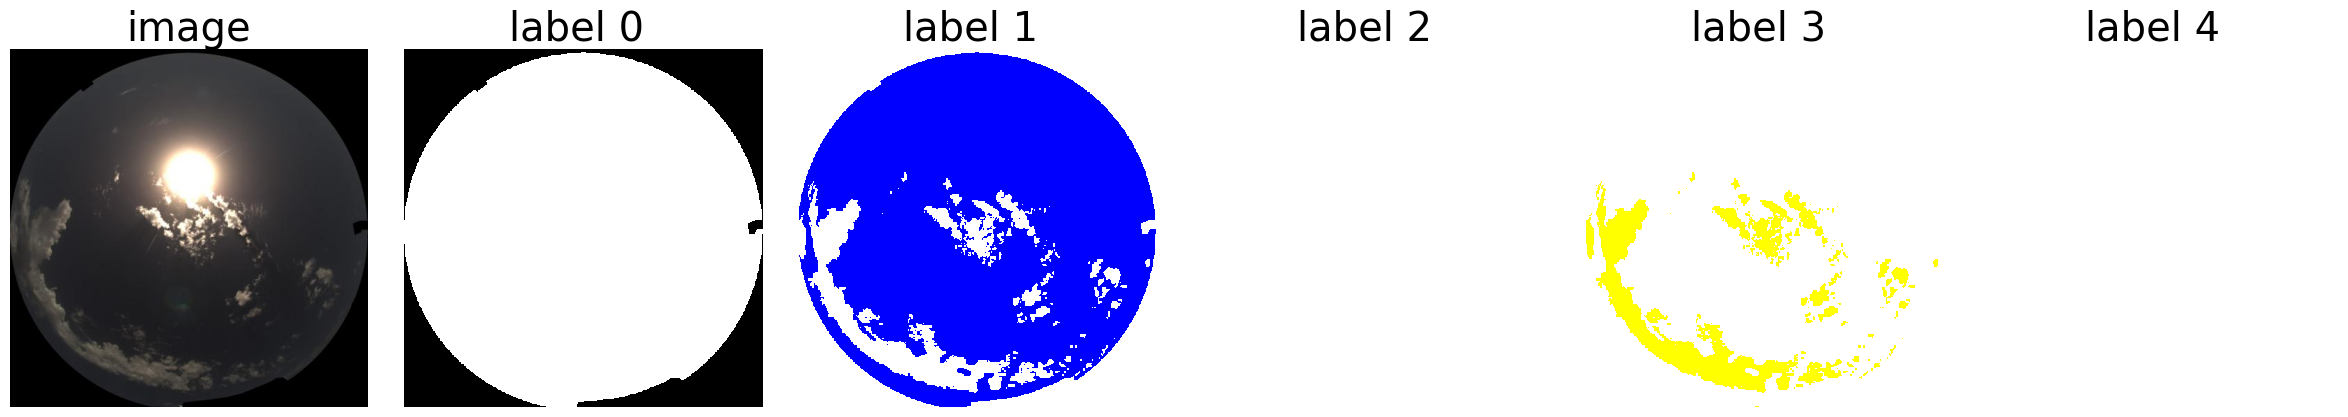

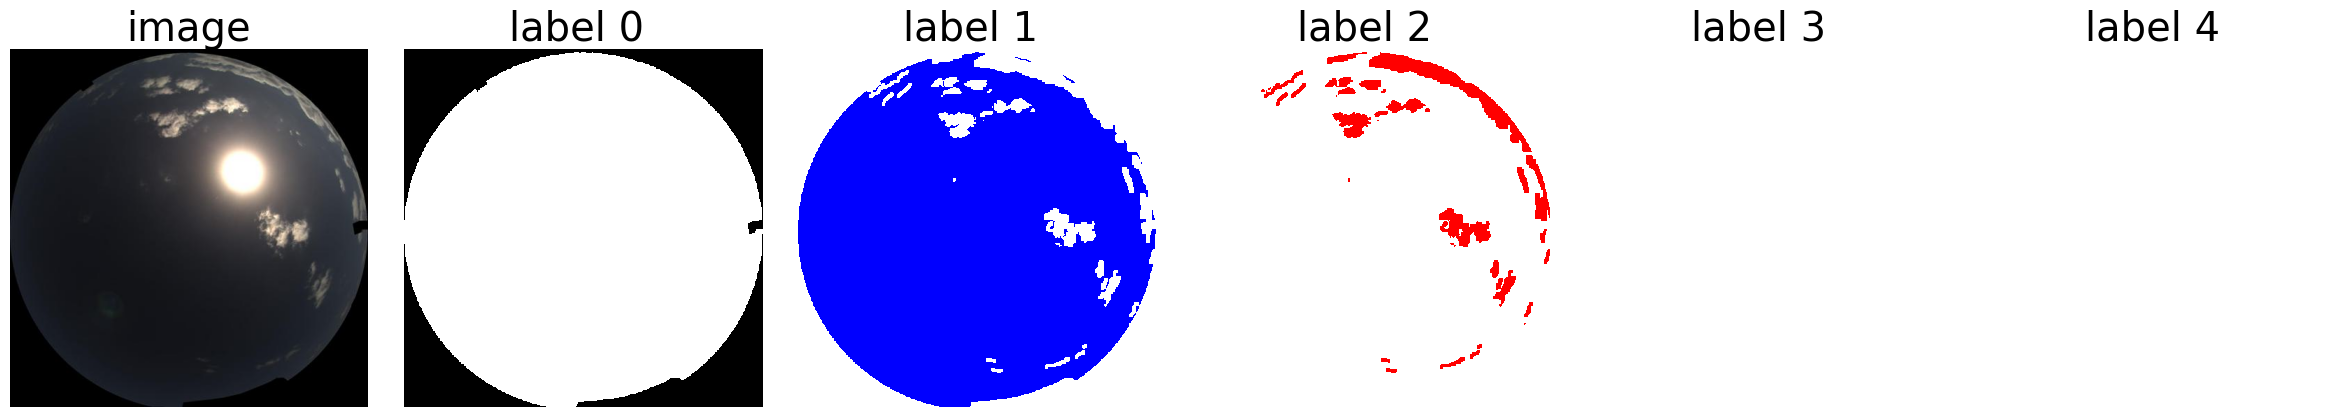

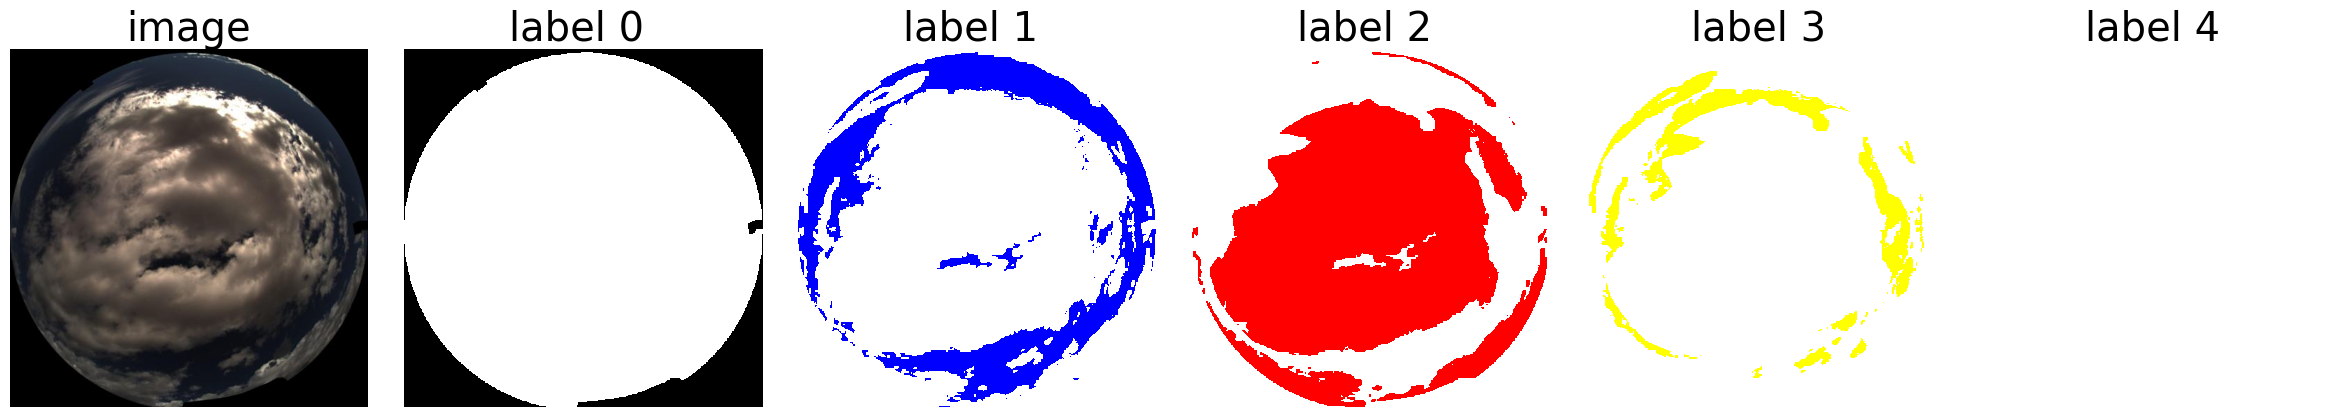

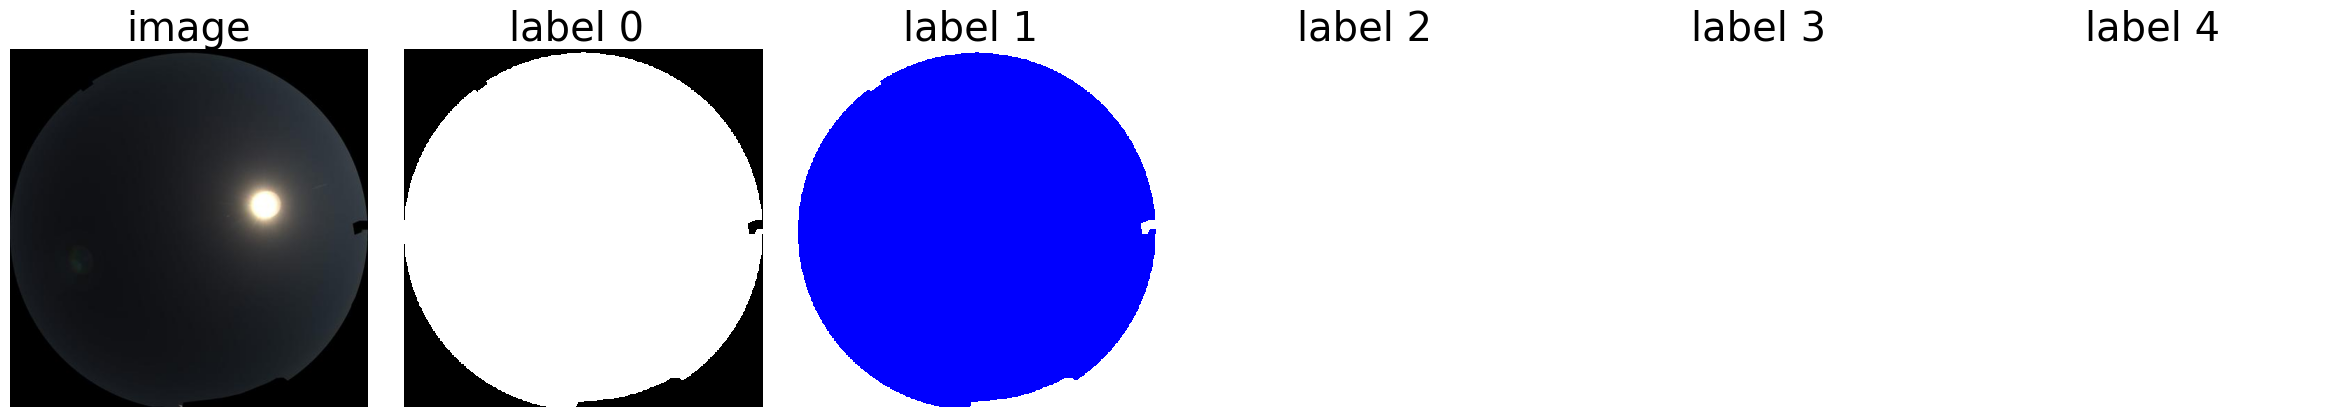

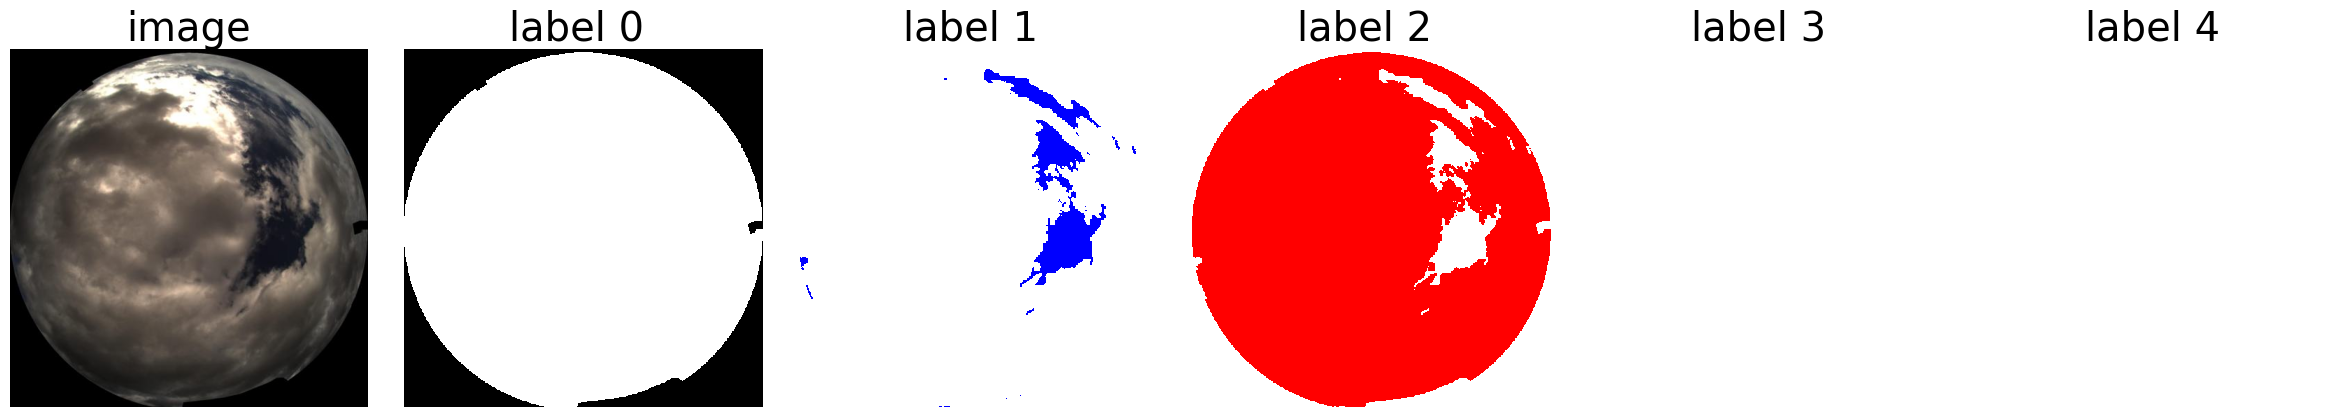

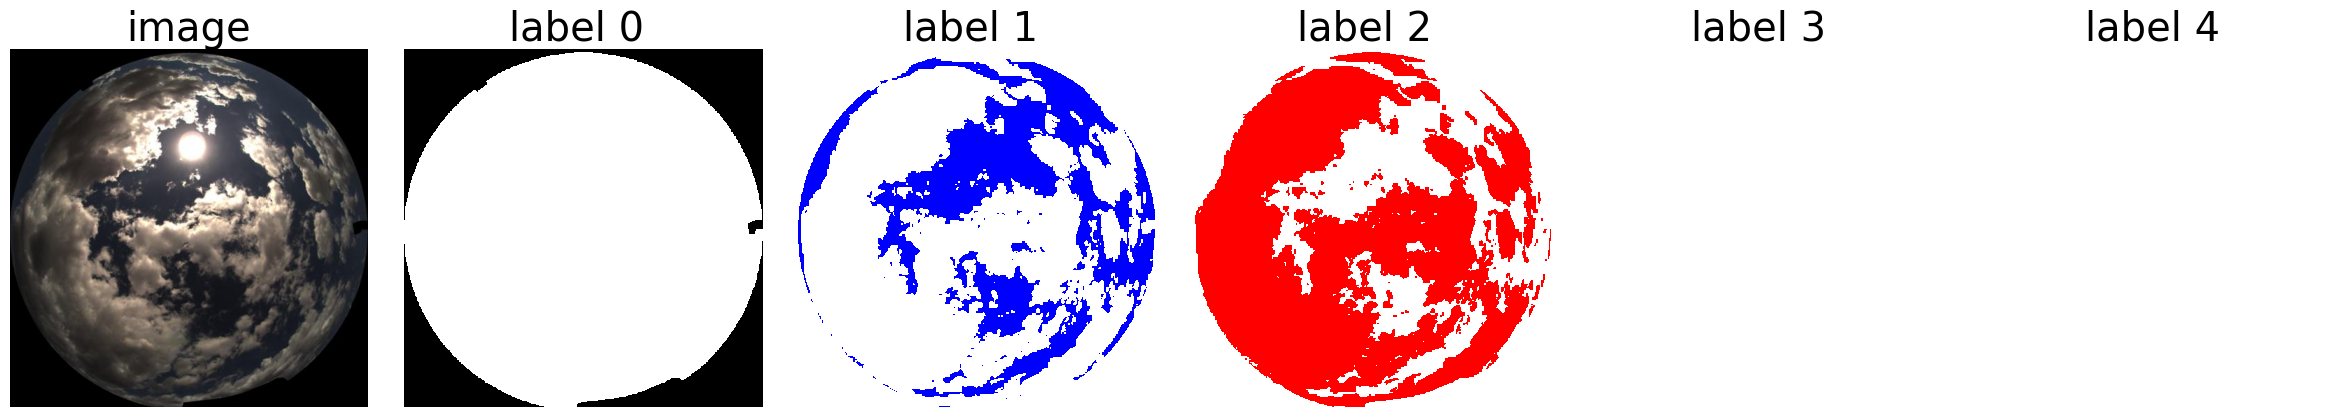

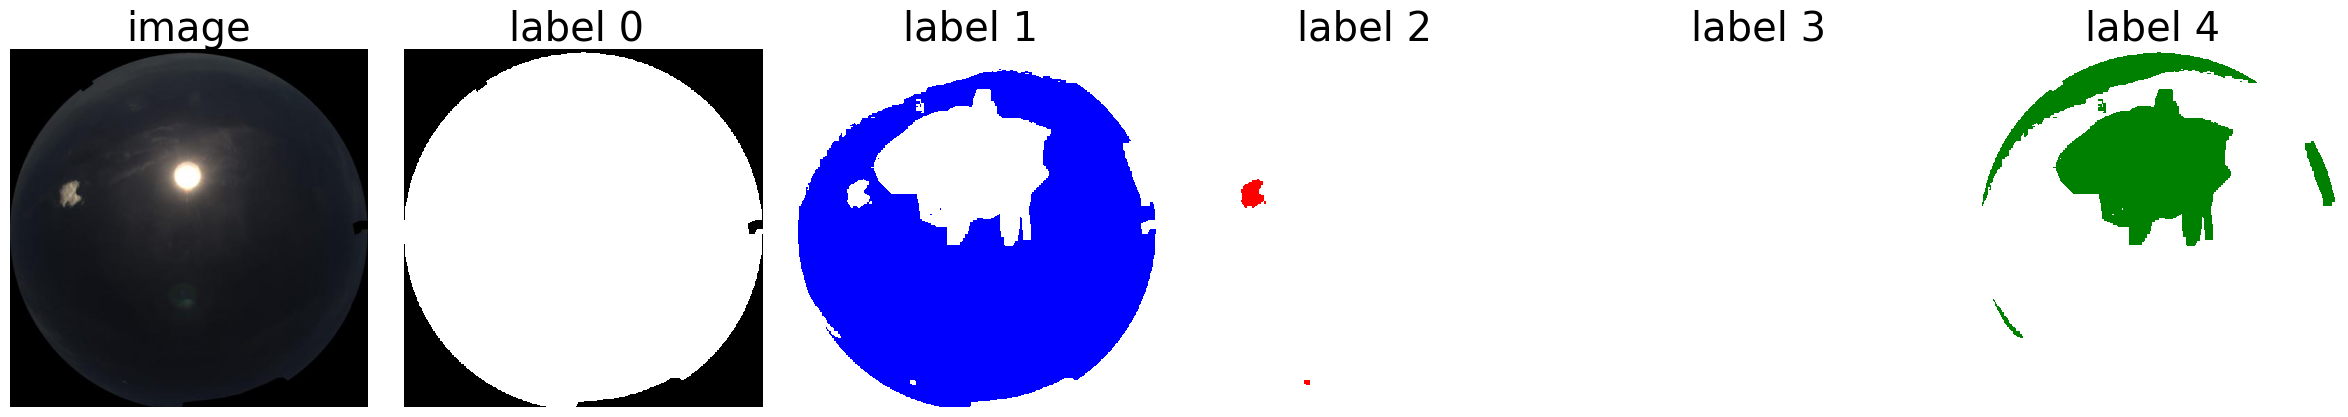

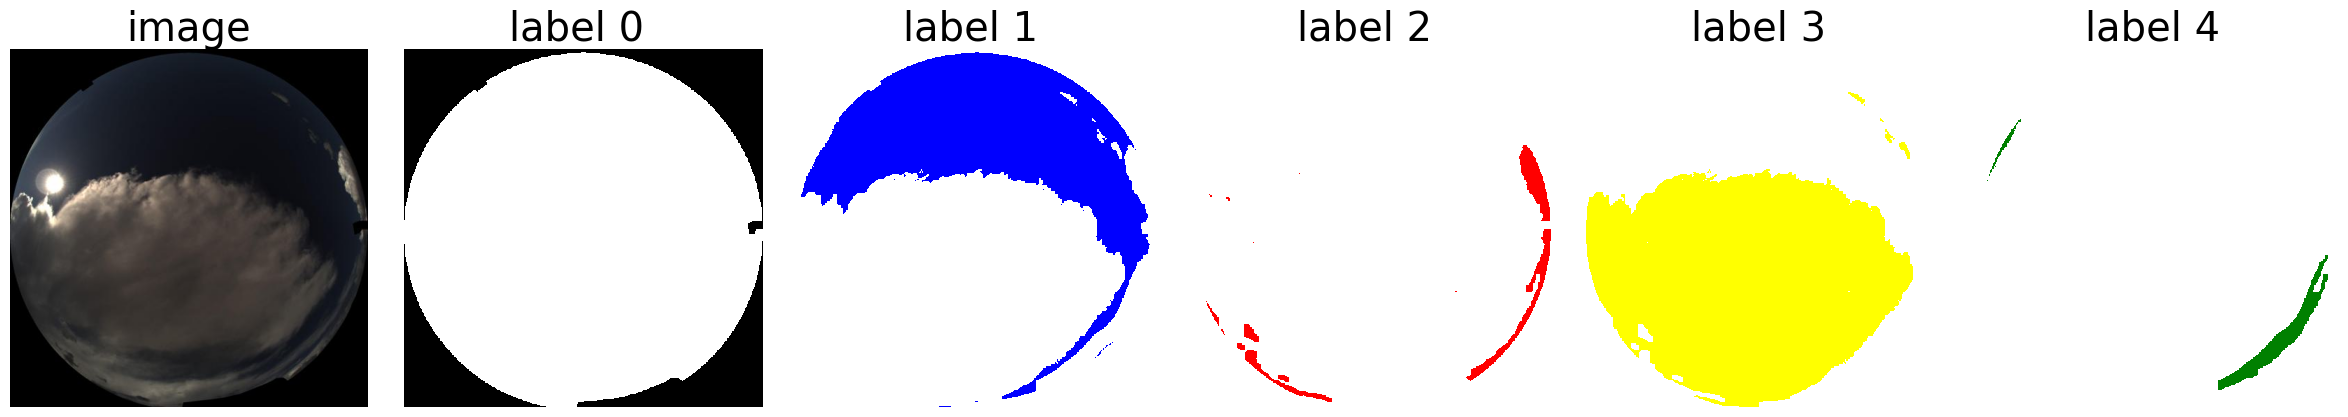

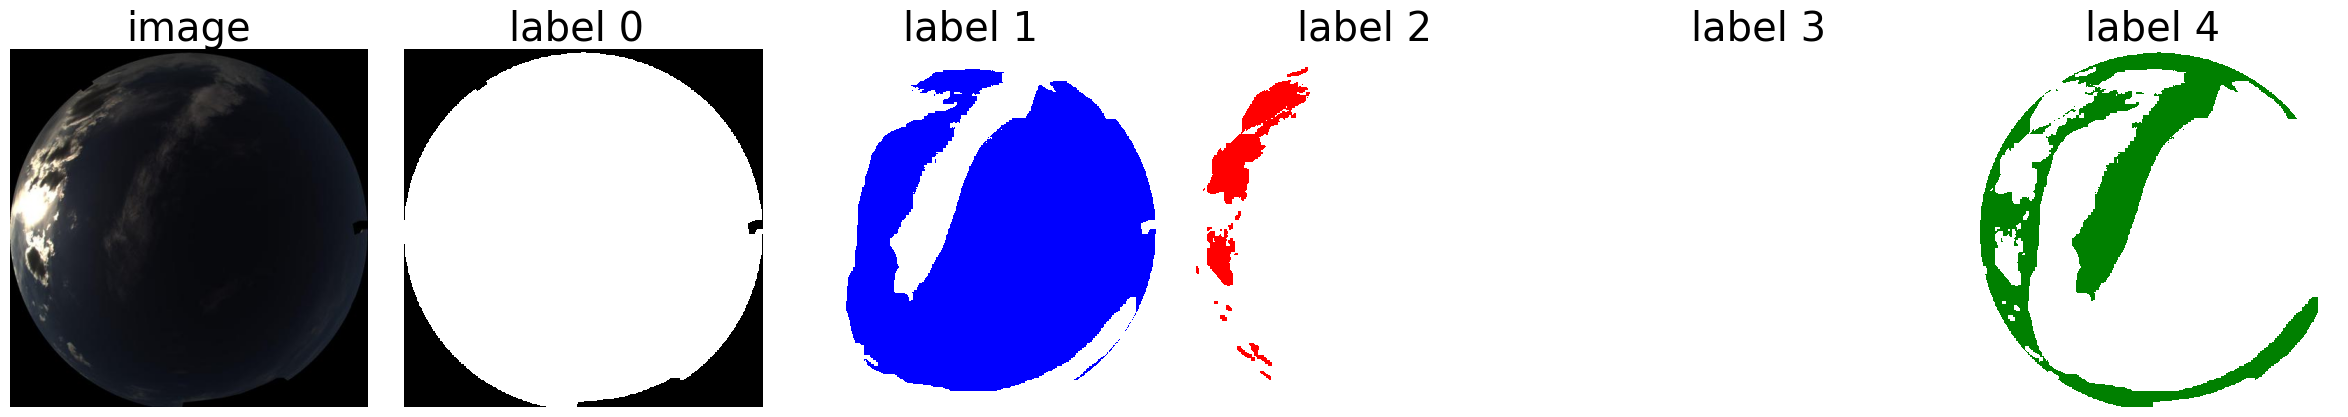

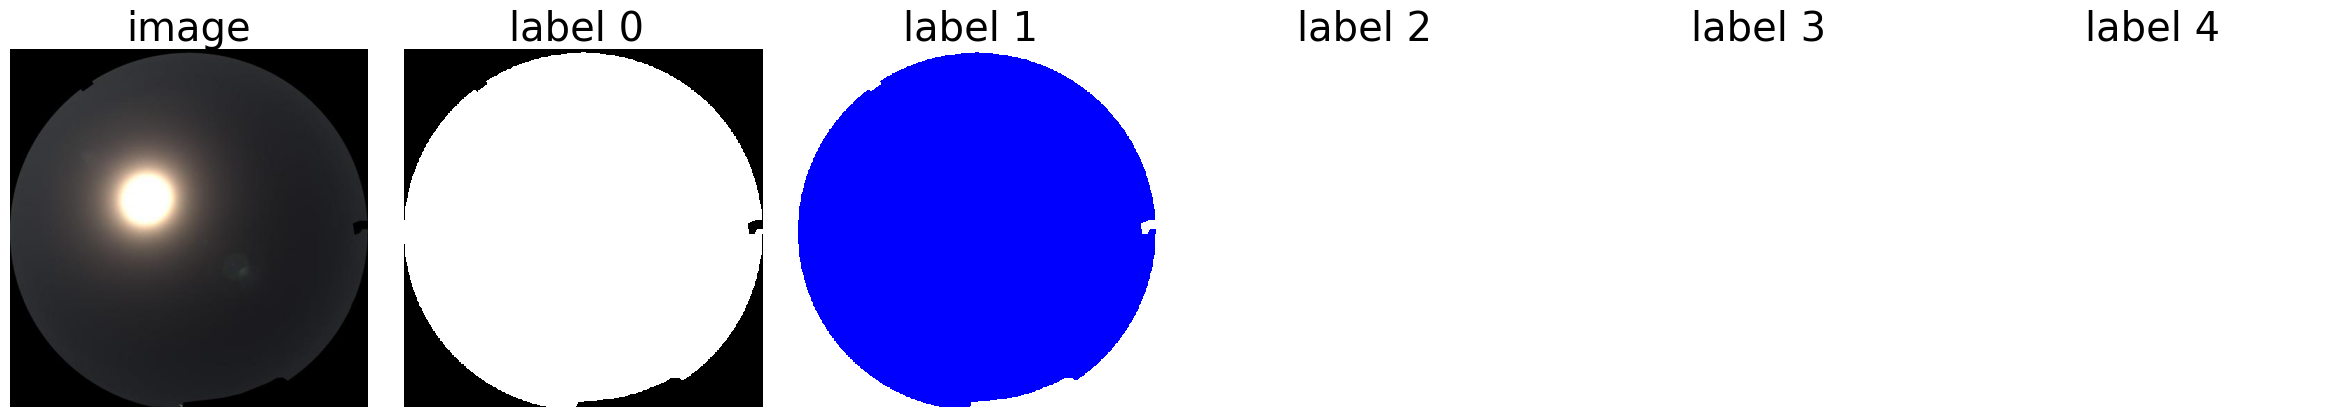

In [11]:
# Consider only the first 10 images

file_names = file_list[:10]

for fileName in file_names:
    # Load images and masks
    image = np.array(Image.open(image_path / f"{fileName}.jpg").convert('RGB'))
    mask = np.array(Image.open(mask_path / f"{fileName}.png"))

    overlay = overlay_mask(image, mask)

    # Plotting
    fig, axes = plt.subplots(1, 6, figsize=(4*(6), 6))

    axes[0].imshow(image)
    axes[0].set_title("image")
    axes[0].axis('off')

    # Define a color map for discrete labels
    cmap = mcolors.ListedColormap(['white', 'black', 'blue', 'red', 'yellow', 'green','gray'])
    bounds = [-1, 0, 1, 2, 3, 4, 5, 6]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)


    for i in range(5):
        mask_only = np.where(mask == i, i, -1)  # nur Label i behalten
        if i == 5:
            mask_only = np.where(mask > 1, i, -1)  # nur Label i behalten
        
        axes[i+1].imshow(mask_only, cmap=cmap, norm=norm, interpolation='nearest')
        
        if i == 0:
            addInfo = 'Background'
        elif i == 1:
            addInfo = 'cloudless sky'
        elif i == 2:
            addInfo = 'low-layer clouds'
        elif i == 3:
            addInfo = 'mid-layer clouds'
        elif i == 4:
            addInfo = 'high-layer clouds'
        elif i == 5:
            addInfo = 'clouds'  
        addInfo = ''          
        axes[i+1].set_title(f"label {i} {addInfo}")

        axes[i+1].axis('off')


    plt.tight_layout()
    plt.show()

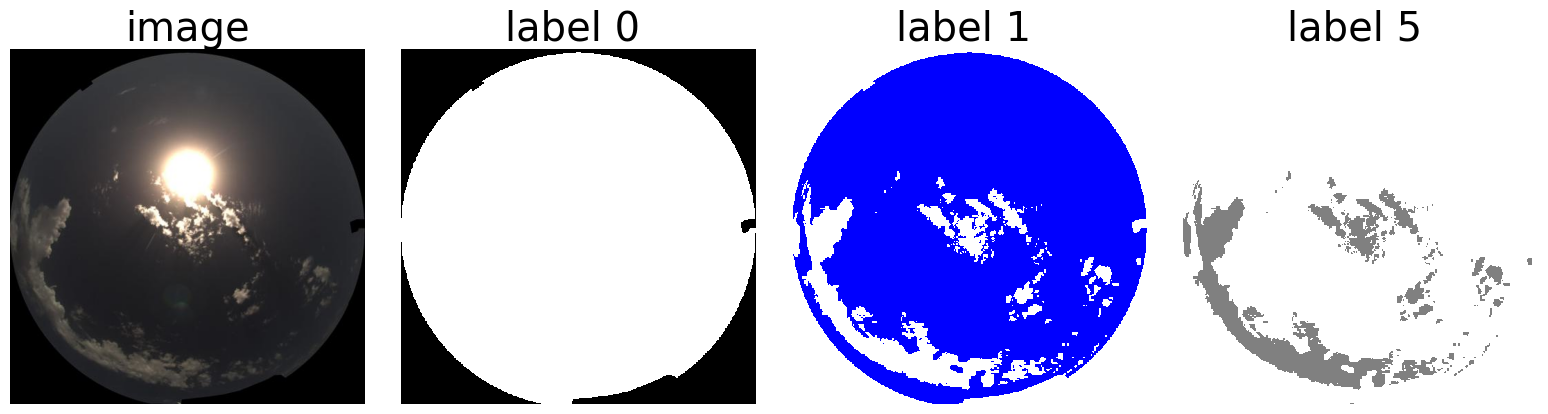

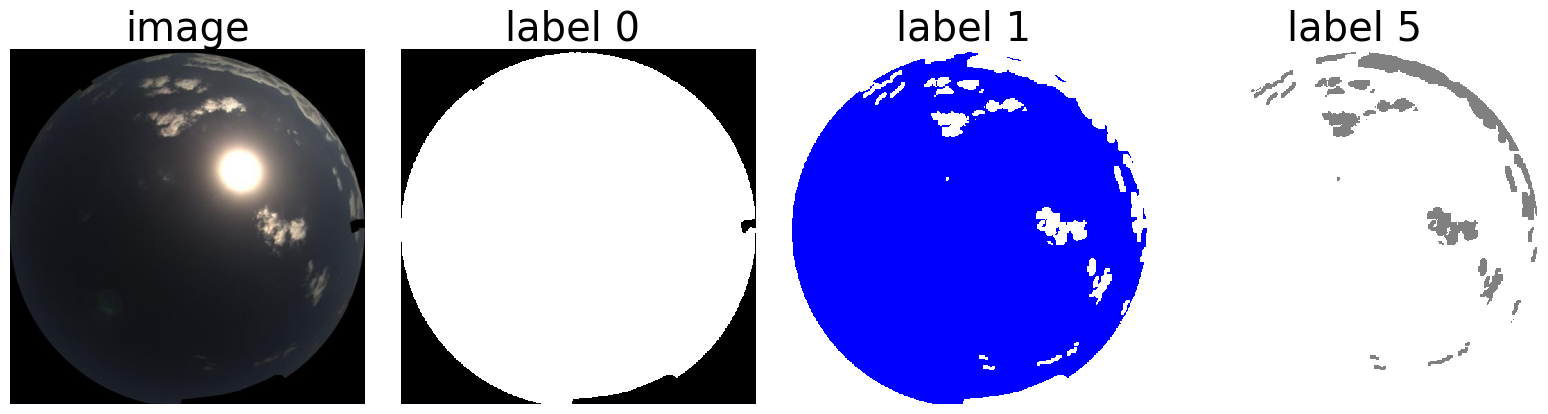

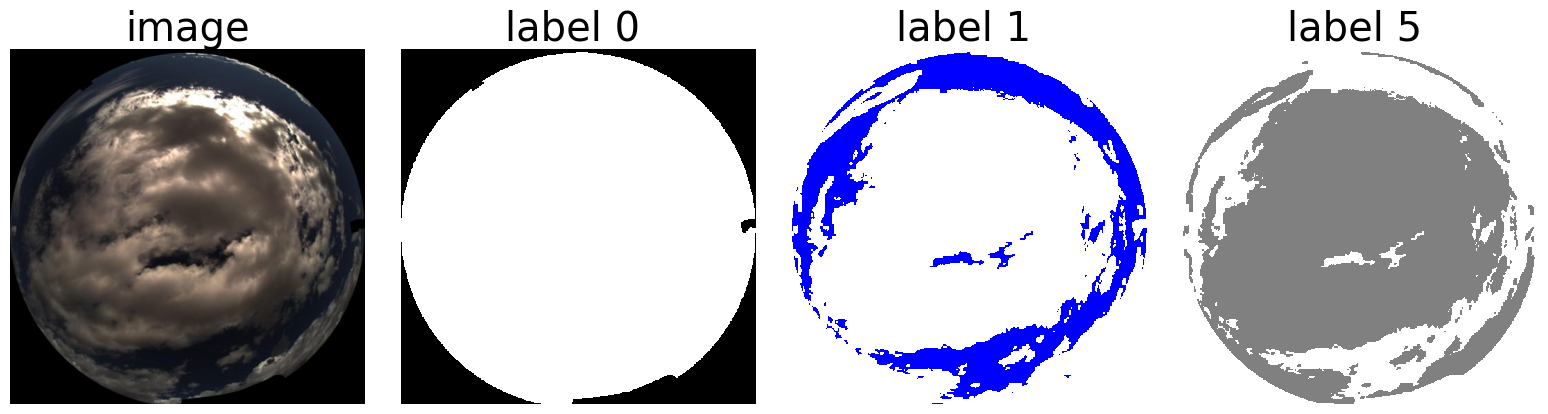

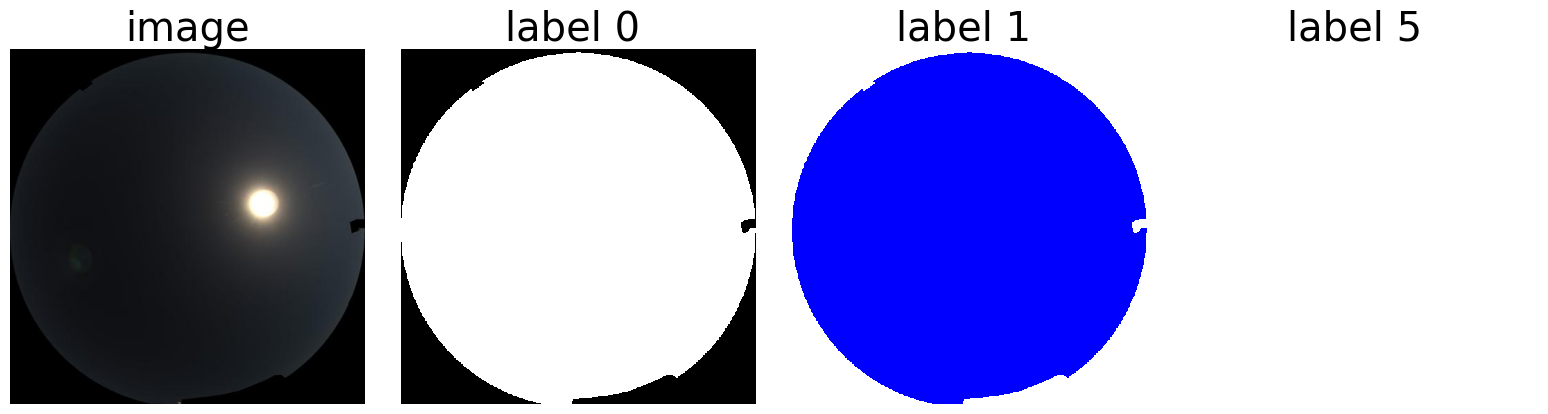

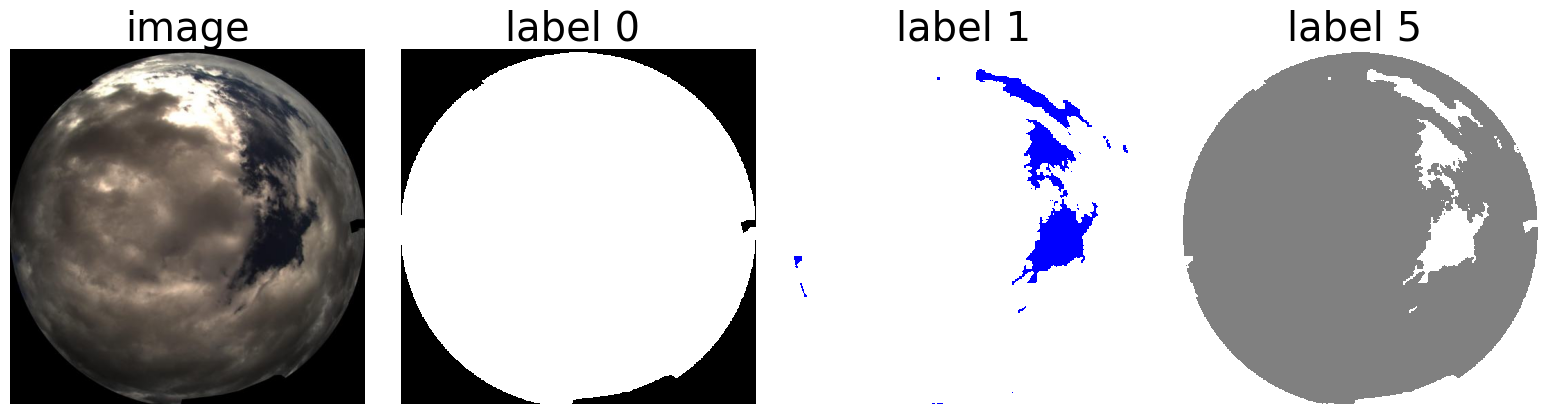

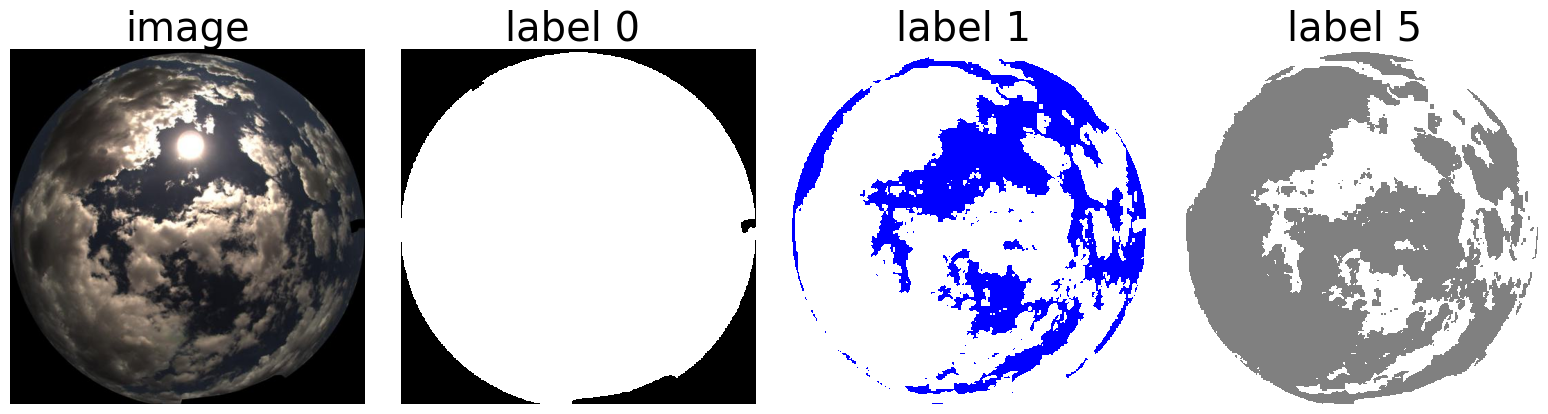

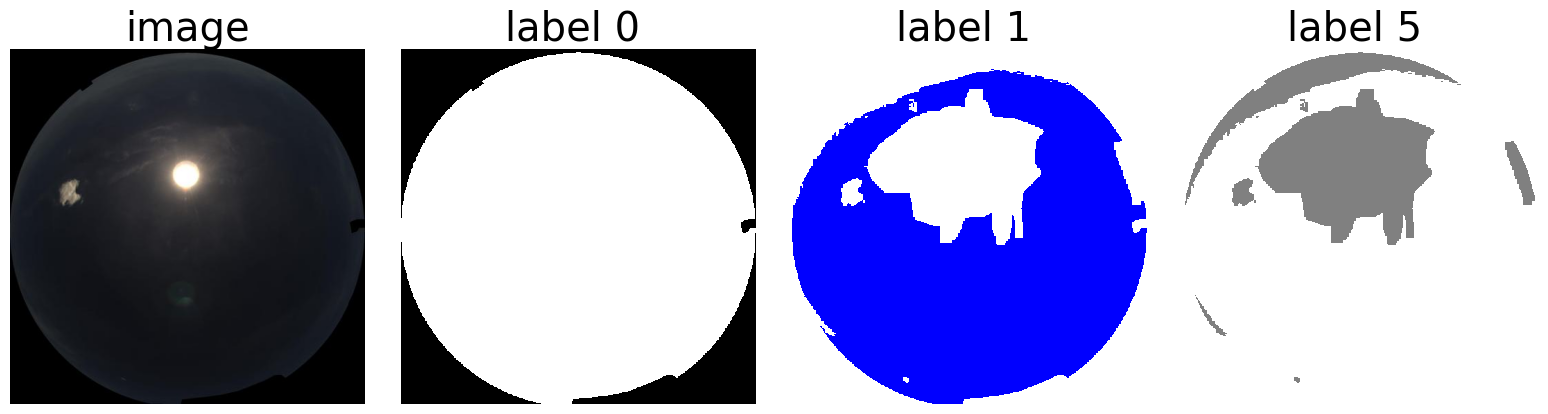

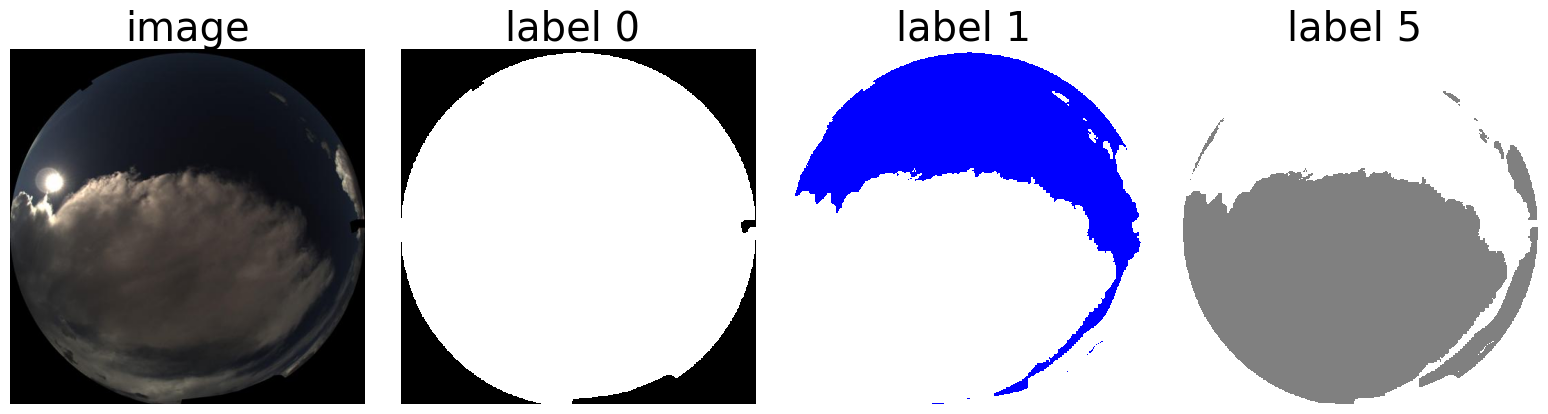

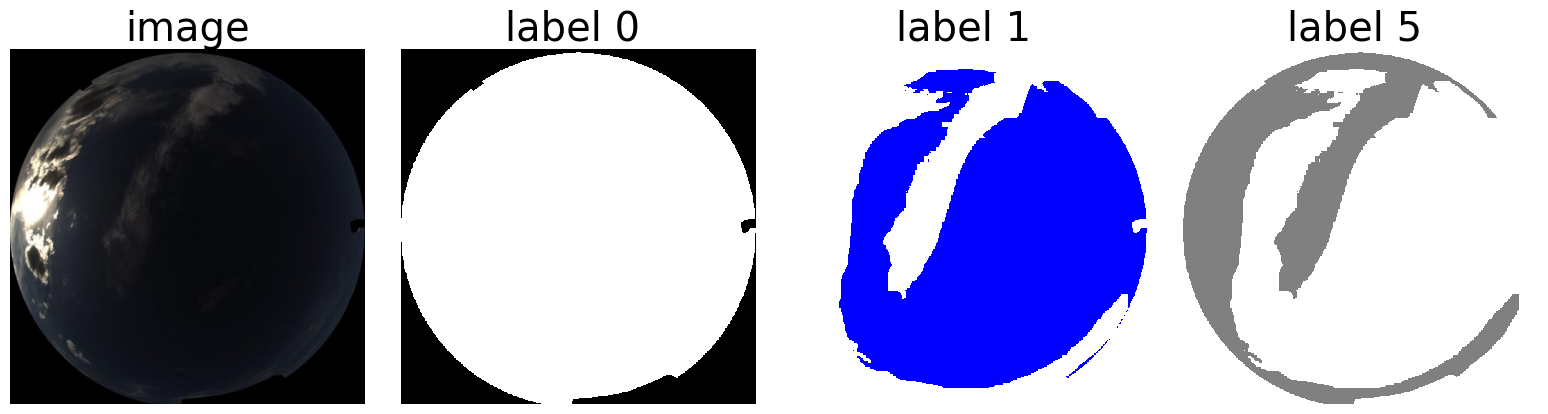

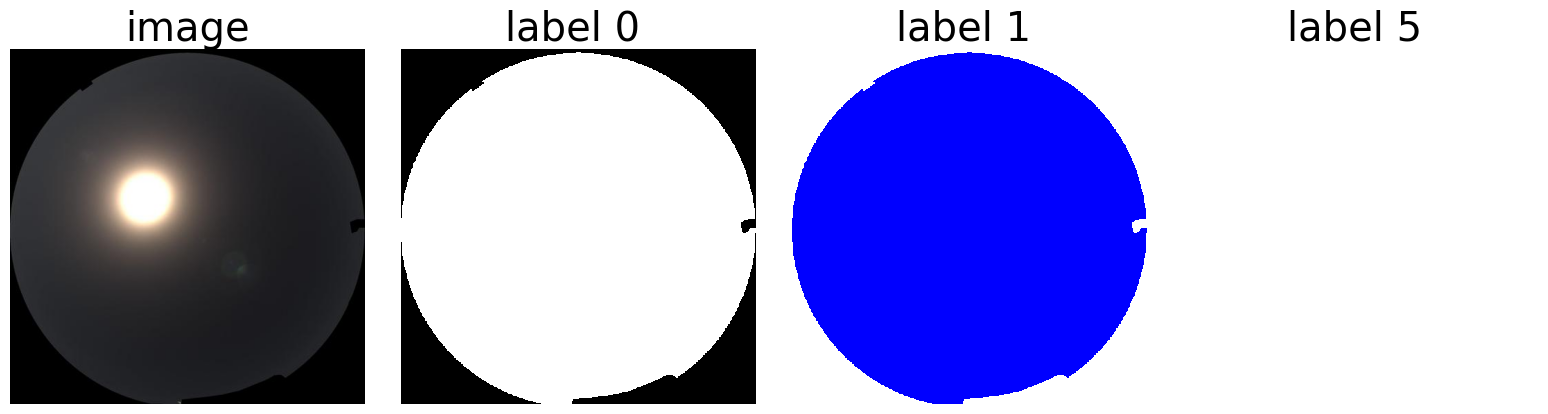

In [12]:
for fileName in file_names:
    # Load images and masks using PIL
    image = np.array(Image.open(image_path / f"{fileName}.jpg").convert('RGB'))
    mask = np.array(Image.open(mask_path / f"{fileName}.png"))

    # Visualization
    overlay = overlay_mask(image, mask)

    # Plotting
    fig, axes = plt.subplots(1, 4, figsize=(4*(4), 6))

    axes[0].imshow(image)
    axes[0].set_title("image")
    axes[0].axis('off')

    # Define a custom color map for discrete labels
    cmap = mcolors.ListedColormap(['white', 'black', 'blue', 'gray', 'yellow', 'green','gray'])
    bounds = [-1, 0, 1, 2, 3, 4, 5, 6]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    has_four = np.any(mask == 2)

    for i in range(3):
        mask_only = np.where(mask == i, i, -1)  # nur Label i behalten
        if i == 2:
            mask_only = np.where(mask > 1, i, -1)  # nur Label i behalten
        
        axes[i+1].imshow(mask_only, cmap=cmap, norm=norm, interpolation='nearest')
        
        if i == 0:
            addInfo = 'Background'
        elif i == 1:
            addInfo = 'cloudless sky'
        elif i == 2:
            addInfo = 'low-layer clouds'
        elif i == 3:
            addInfo = 'mid-layer clouds'
        elif i == 4:
            addInfo = 'high-layer clouds'
        elif i == 5:
            addInfo = 'clouds'  
        addInfo = ''   

        if i == 2:
            axes[i+1].set_title(f"label 5 {addInfo}")
        else:
            axes[i+1].set_title(f"label {i} {addInfo}")
  
        axes[i+1].axis('off')

    plt.tight_layout()
    plt.show()